In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df=pd.read_csv(r"C:\Users\Acer\OneDrive - ut.edu.vn\Documents\DATA ANALYST\diabetes.csv")

In [3]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.shape

(768, 9)

Kiem tra du lieu null

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

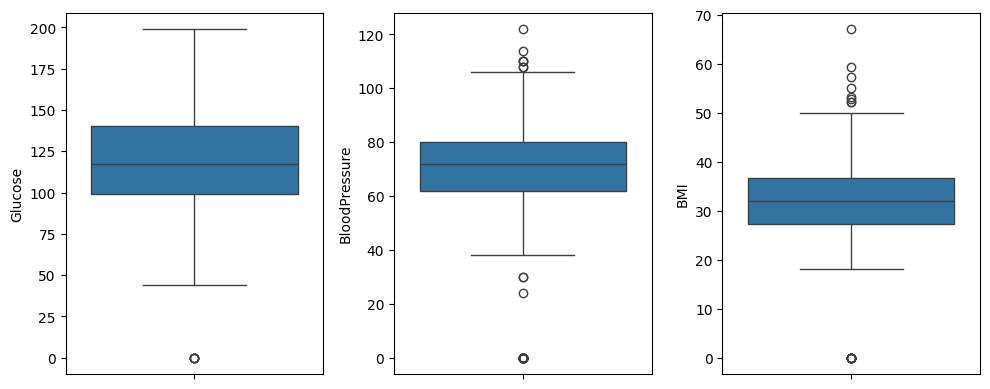

In [6]:
column_category=['Glucose','BloodPressure','BMI']
plt.figure(figsize=(10,4))
for i,col in enumerate(column_category):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()


In [7]:
# Do cac chi so BMI, Glu, BloodPressure co vai chi so = 0 
# Can phai chuan hoa du lieu theo gia tri trung vi(vi co nhieu gia tri outiler)
# Vi khi co gia tri outiler dien gia tri mean se lam sai lech ket qua

In [8]:
# Chuyen cac gia tri = 0 thanh nan
df[column_category]=df[column_category].replace(0,np.nan)

In [9]:
# Chuyen cac gia tri nan thanh median
df[column_category]=df[column_category].fillna(df[column_category].median())

In [10]:
# Chuẩn hóa các chỉ số thành các biến phân loại 
# Thấp: 0,140 | Cao: 500
label_Glu=['Thấp','Cao']
bin_glu=[0,140,500]
# Gầy:0,25 | Béo:100
label_BMI=['Gầy','Béo']
bin_bmi=[0,25,100]
# Trẻ:0,40,120
label_Age=['Trẻ','Già']
bin_age=[0,40,120]

In [11]:
df['Glucose_cat']=pd.cut(df['Glucose'],bins=bin_glu,labels=label_Glu,right=False)
df['BMI_cat']=pd.cut(df['BMI'],bins=bin_bmi,labels=label_BMI,right=False)
df['Age_cat']=pd.cut(df['Age'],bins=bin_age,labels=label_Age,right=False)

In [73]:
df_sample=df[['Glucose_cat','BMI_cat','Age_cat','Outcome']].sample(n=10,random_state=17)

In [74]:
df_sample

,Glucose_cat,BMI_cat,Age_cat,Outcome
649,Thấp,Béo,Trẻ,0
516,Cao,Béo,Già,1
151,Thấp,Gầy,Trẻ,0
381,Thấp,Gầy,Trẻ,0
325,Cao,Béo,Trẻ,0
473,Thấp,Béo,Già,0
736,Thấp,Béo,Trẻ,0
300,Cao,Béo,Trẻ,1
662,Cao,Béo,Già,1
484,Cao,Béo,Trẻ,1


In [ ]:
df.to_csv('diabetes_clean.csv')
df_sample.to_csv('diabetes_sample.csv')